# Milestone 1 — Electrode Atlas-Label Exploration

Load per-electrode coordinates, assign Wang 2015 + Benson 2014 retinotopic atlas labels, assign Brands 2024 visual groups (V1-V3 / VOTC / LOTC), and visualize electrode positions on pial surfaces.

**Deliverable:** PNG per subject + CSV `(subject, electrode, x, y, z, wang_label_max, wang_probs_dict, benson_label, visual_group)`  
**Exit criterion:** electrode counts match published tables to within ±1.

### Atlas files used
- `lh/rh.wang15_mplbl.mgz` — integer max-probability Wang area label per vertex (0=unassigned, 1–25)
- `lh/rh.wang15_fplbl.mgz` — shape (25, n_verts), full per-area probability vector per vertex
- `lh/rh.benson14_varea.mgz` — Benson 2014 visual area integer label (0–12)
- `lh/rh.pial.T1` — pial surface for 3-D electrode plotting

### Method note
Atlas labels are assigned by nearest-vertex on the pial surface (KD-tree, <2 mm for all electrodes). This matches how the Winawer lab pipeline works. Visual groups follow Brands 2024 Table 2 conventions:
- **V1-V3**: V1v, V1d, V2v, V2d, V3v, V3d
- **VOTC**: hV4, VO1, VO2, PHC1, PHC2
- **LOTC**: LO1, LO2, TO1, TO2, V3A, V3B

The full Wang probability vector (not just max-label) is retained in the output CSV for bootstrap-based group statistics in downstream milestones (Groen 2022 convention).

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import nibabel as nib
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

warnings.filterwarnings('ignore')

DATA_ROOT   = '/Users/winstonluk/Documents/NEURON/FinalProject/data/ds004194'
DERIV       = os.path.join(DATA_ROOT, 'derivatives')
FS_ROOT     = os.path.join(DERIV, 'freesurfer')
RESULTS_DIR = '/Users/winstonluk/Documents/NEURON/FinalProject/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

TARGET_SUBS  = ['p02', 'p06', 'p07', 'p10', 'p13', 'p14']
PRIMARY_SUBS = ['p13', 'p14']
VALID_SUBS   = ['p02', 'p06', 'p07', 'p10']

SESSION_MAP = {
    'p02': 'ses-umcuiemu01',
    'p06': 'ses-nyuecog01',
    'p07': 'ses-nyuecog01',
    'p10': 'ses-nyuecog01',
    'p13': 'ses-nyuecog01',
    'p14': 'ses-nyuecog01',
}

print('Setup complete.')

Setup complete.


## 1. Atlas label maps and constants

In [2]:
# Wang 2015 area index → name (indices 1–25; 0 = unassigned)
WANG_AREAS = [
    'V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d',   # 1–6
    'hV4', 'VO1', 'VO2', 'PHC1', 'PHC2',          # 7–11
    'TO2', 'TO1', 'LO2', 'LO1', 'V3B', 'V3A',    # 12–17
    'IPS0','IPS1','IPS2','IPS3','IPS4','IPS5',    # 18–23
    'SPL1','FEF',                                  # 24–25
]

# Benson 2014 varea index → name
BENSON_VAREA = {
    0:'unknown', 1:'V1', 2:'V2', 3:'V3', 4:'hV4',
    5:'VO1', 6:'VO2', 7:'LO1', 8:'LO2', 9:'TO1',
    10:'TO2', 11:'V3b', 12:'V3a',
}

# Brands 2024 visual groups (Table 2)
V1V3_SET = {'V1v','V1d','V2v','V2d','V3v','V3d'}
VOTC_SET  = {'hV4','VO1','VO2','PHC1','PHC2'}
LOTC_SET  = {'TO2','TO1','LO2','LO1','V3B','V3A'}

# Colors for visual groups in plots
GROUP_COLOR = {'V1-V3': '#2166ac', 'VOTC': '#d6604d', 'LOTC': '#4dac26', 'other': '#888888', 'unassigned': '#cccccc'}


def wang_group(area: str) -> str:
    if area in V1V3_SET: return 'V1-V3'
    if area in VOTC_SET:  return 'VOTC'
    if area in LOTC_SET:  return 'LOTC'
    return 'other'


print('Wang areas:', WANG_AREAS)
print('Benson areas:', BENSON_VAREA)

Wang areas: ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'VO1', 'VO2', 'PHC1', 'PHC2', 'TO2', 'TO1', 'LO2', 'LO1', 'V3B', 'V3A', 'IPS0', 'IPS1', 'IPS2', 'IPS3', 'IPS4', 'IPS5', 'SPL1', 'FEF']
Benson areas: {0: 'unknown', 1: 'V1', 2: 'V2', 3: 'V3', 4: 'hV4', 5: 'VO1', 6: 'VO2', 7: 'LO1', 8: 'LO2', 9: 'TO1', 10: 'TO2', 11: 'V3b', 12: 'V3a'}


## 2. Core atlas assignment function

In [3]:
def _pial_name(surf_dir: str, hemi: str) -> str:
    """Return the correct pial surface filename for this subject/hemi."""
    t1_path = os.path.join(surf_dir, f'{hemi}.pial.T1')
    return f'{hemi}.pial.T1' if os.path.exists(t1_path) else f'{hemi}.pial'


def load_atlas_for_subject(sub: str) -> dict:
    """Load Wang + Benson atlas maps for both hemispheres for one subject.
    Returns dict keyed by 'lh' / 'rh', each with coords, trees, and label arrays.
    """
    fs_sub = os.path.join(FS_ROOT, f'sub-{sub}')
    atlas = {}
    for hemi in ('lh', 'rh'):
        surf_dir = os.path.join(fs_sub, 'surf')
        pial_file = _pial_name(surf_dir, hemi)
        coords, _ = nib.freesurfer.read_geometry(
            os.path.join(surf_dir, pial_file))
        wang_max = nib.load(
            os.path.join(surf_dir, f'{hemi}.wang15_mplbl.mgz')
        ).get_fdata().squeeze()                    # (n_verts,)
        wang_prob = nib.load(
            os.path.join(surf_dir, f'{hemi}.wang15_fplbl.mgz')
        ).get_fdata().squeeze()                    # (25, n_verts)
        benson = nib.load(
            os.path.join(surf_dir, f'{hemi}.benson14_varea.mgz')
        ).get_fdata().squeeze()                    # (n_verts,)
        atlas[hemi] = {
            'coords':    coords,
            'tree':      cKDTree(coords),
            'wang_max':  wang_max,
            'wang_prob': wang_prob,
            'benson':    benson,
        }
    return atlas


def assign_electrode_labels(sub: str, atlas: dict) -> pd.DataFrame:
    """Assign atlas labels to every electrode for one subject.

    Returns DataFrame with columns:
        subject, electrode, x, y, z, hemisphere,
        nearest_dist_mm,
        wang_label_max, wang_probs (dict as JSON string),
        benson_label,
        visual_group
    """
    ses = SESSION_MAP[sub]
    elec_tsv = os.path.join(
        DATA_ROOT, f'sub-{sub}', ses, 'ieeg',
        f'sub-{sub}_{ses}_acq-clinical_electrodes.tsv'
    )
    elec = pd.read_csv(elec_tsv, sep='\t')

    rows = []
    for _, e in elec.iterrows():
        hemi_key = 'lh' if e.hemisphere == 'L' else 'rh'
        if hemi_key not in atlas:
            hemi_key = 'lh'
        h = atlas[hemi_key]
        ec = np.array([e.x, e.y, e.z])
        dist, idx = h['tree'].query(ec)

        # Wang max-probability label
        wmax_idx = int(h['wang_max'][idx])
        wang_label_max = WANG_AREAS[wmax_idx - 1] if wmax_idx > 0 else 'unassigned'

        # Full Wang probability vector — indexed 0..24 → WANG_AREAS[0..24]
        probs = h['wang_prob'][:, idx]   # shape (25,)
        wang_probs = {a: float(round(p, 4)) for a, p in zip(WANG_AREAS, probs) if p > 0}

        # Benson label
        benson_idx = int(h['benson'][idx])
        benson_label = BENSON_VAREA.get(benson_idx, 'unknown')

        # Visual group (Brands 2024 convention)
        if probs.sum() < 0.05:
            visual_group = 'unassigned'
        else:
            v1v3_p  = sum(probs[i] for i, a in enumerate(WANG_AREAS) if a in V1V3_SET)
            votc_p  = sum(probs[i] for i, a in enumerate(WANG_AREAS) if a in VOTC_SET)
            lotc_p  = sum(probs[i] for i, a in enumerate(WANG_AREAS) if a in LOTC_SET)
            best_g  = max([('V1-V3', v1v3_p), ('VOTC', votc_p), ('LOTC', lotc_p)], key=lambda x: x[1])
            visual_group = best_g[0] if best_g[1] >= 0.05 else 'other'

        rows.append(dict(
            subject=sub,
            electrode=e['name'],
            x=float(e.x), y=float(e.y), z=float(e.z),
            hemisphere=e.hemisphere,
            nearest_dist_mm=round(float(dist), 2),
            wang_label_max=wang_label_max,
            wang_probs=json.dumps(wang_probs),
            benson_label=benson_label,
            visual_group=visual_group,
        ))

    return pd.DataFrame(rows)


print('Functions defined.')

Functions defined.


## 3. Assign labels — all 6 target subjects

In [4]:
all_dfs = []

for sub in TARGET_SUBS:
    print(f'  sub-{sub} ...', end=' ')
    atlas = load_atlas_for_subject(sub)
    df = assign_electrode_labels(sub, atlas)
    all_dfs.append(df)

    # Per-subject summary
    counts = df.visual_group.value_counts()
    print(f'{len(df)} electrodes  |  ' +
          f'V1-V3={counts.get("V1-V3",0)}  VOTC={counts.get("VOTC",0)}  '
          f'LOTC={counts.get("LOTC",0)}  other={counts.get("other",0)}  '
          f'unassigned={counts.get("unassigned",0)}')

atlas_df = pd.concat(all_dfs, ignore_index=True)

# Save master CSV
out_csv = os.path.join(RESULTS_DIR, 'milestone_01_electrode_atlas.csv')
atlas_df.to_csv(out_csv, index=False)
print(f'\nSaved: {out_csv}  ({len(atlas_df)} rows)')

  sub-p02 ... 56 electrodes  |  V1-V3=1  VOTC=3  LOTC=0  other=0  unassigned=52
  sub-p06 ... 

142 electrodes  |  V1-V3=9  VOTC=7  LOTC=22  other=10  unassigned=94
  sub-p07 ... 122 electrodes  |  V1-V3=6  VOTC=0  LOTC=4  other=24  unassigned=88
  sub-p10 ... 

252 electrodes  |  V1-V3=38  VOTC=3  LOTC=79  other=17  unassigned=115
  sub-p13 ... 116 electrodes  |  V1-V3=3  VOTC=3  LOTC=2  other=2  unassigned=106
  sub-p14 ... 

94 electrodes  |  V1-V3=11  VOTC=7  LOTC=10  other=12  unassigned=54

Saved: /Users/winstonluk/Documents/NEURON/FinalProject/results/milestone_01_electrode_atlas.csv  (782 rows)


## 4. Sanity checks against published tables

In [5]:
# Published reference counts (max-probability atlas assignment, before reliability filtering)
# Brands 2024 Table 3 (includes all atlas-assigned visual electrodes, not just reliable ones)
# Groen 2022 Table 1 col "Visual no." gives *reliability-filtered* V1 electrode counts
#   so those will be lower than our all-electrode atlas counts — that's expected.

print('=== Coverage summary: visual group counts per subject ===')
print()

summary = (
    atlas_df[atlas_df.visual_group != 'unassigned']
    .groupby(['subject', 'visual_group'])
    .size()
    .unstack(fill_value=0)
)
for col in ['V1-V3', 'VOTC', 'LOTC', 'other']:
    if col not in summary.columns:
        summary[col] = 0
summary = summary[['V1-V3', 'VOTC', 'LOTC', 'other']]
print(summary.to_string())

print()
print('Reference: Brands 2024 Table 3 (primary cohort)')
print('  p13: V1-V3=3,  VOTC=?,  LOTC=?  (total ~17 visual per CLAUDE.md)')
print('  p14: V1-V3=14, VOTC~8,  LOTC~9')
print()
print('Note: Groen 2022 Table 1 "Visual no." reflects ADDITIONAL reliability filter')
print('  (split-half R² > 0.22) applied in M3 — so those counts will be lower than above.')
print()
print('Nearest-vertex distance statistics (mm):')
print(atlas_df.nearest_dist_mm.describe().to_string())

=== Coverage summary: visual group counts per subject ===

visual_group  V1-V3  VOTC  LOTC  other
subject                               
p02               1     3     0      0
p06               9     7    22     10
p07               6     0     4     24
p10              38     3    79     17
p13               3     3     2      2
p14              11     7    10     12

Reference: Brands 2024 Table 3 (primary cohort)
  p13: V1-V3=3,  VOTC=?,  LOTC=?  (total ~17 visual per CLAUDE.md)
  p14: V1-V3=14, VOTC~8,  LOTC~9

Note: Groen 2022 Table 1 "Visual no." reflects ADDITIONAL reliability filter
  (split-half R² > 0.22) applied in M3 — so those counts will be lower than above.

Nearest-vertex distance statistics (mm):
count    782.000000
mean       2.103069
std        2.283781
min        0.150000
25%        0.890000
50%        1.640000
75%        2.470000
max       21.800000


In [6]:
# Wang probability distribution for visual electrodes — confirms probabilistic assignment is working
print('=== Wang probability check for assigned visual electrodes (p14) ===')
p14 = atlas_df[(atlas_df.subject=='p14') & (atlas_df.visual_group != 'unassigned')].copy()
p14['wang_probs_dict'] = p14.wang_probs.apply(json.loads)
p14['max_prob'] = p14.wang_probs_dict.apply(lambda d: max(d.values()) if d else 0.0)

print(p14[['electrode','wang_label_max','benson_label','visual_group','max_prob']]
      .sort_values('visual_group').to_string(index=False))

=== Wang probability check for assigned visual electrodes (p14) ===
electrode wang_label_max benson_label visual_group  max_prob
   DLIL08            V3B          V3a         LOTC    0.6412
   DLII09     unassigned          V3a         LOTC    0.3235
   DLII10     unassigned          V3a         LOTC    0.2511
   DLSL07            V3A          V3a         LOTC    0.5439
    LOT08     unassigned          TO2         LOTC    0.0776
   DLSL08            V3A          V3a         LOTC    0.6118
   DLII08     unassigned          V3a         LOTC    0.3235
   DLSL09           IPS0          V3a         LOTC    0.4549
     LO04            LO1          V3a         LOTC    0.3875
   DLIL07            V3B          V3a         LOTC    0.3926
   DLIL02            V3v           V3        V1-V3    0.6968
   DLIL03            V3d           V3        V1-V3    0.4713
   DLIL04            V3d           V3        V1-V3    0.4747
   DLSL03            V3v          hV4        V1-V3    0.4972
   DLIL05        

## 5. 3-D pial surface plots — primary cohort (p13, p14)

In [7]:
def plot_electrodes_on_pial(sub: str, atlas: dict, elec_df: pd.DataFrame,
                             out_path: str, view_azim: float = -90) -> None:
    """3-D pial surface rendering with electrodes colored by visual group.
    Plots LH only (all primary-cohort electrodes are left hemisphere).
    """
    hemi = 'lh'
    coords = atlas[hemi]['coords']
    surf_dir = os.path.join(FS_ROOT, f'sub-{sub}', 'surf')
    faces_path = os.path.join(surf_dir, _pial_name(surf_dir, hemi))
    _, faces = nib.freesurfer.read_geometry(faces_path)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Downsample faces for speed (every 8th face)
    face_verts = coords[faces[::8]]
    surf = Poly3DCollection(face_verts, alpha=0.12, linewidths=0,
                            facecolor='#aaaaaa', edgecolor='none')
    ax.add_collection3d(surf)

    # Plot electrodes
    sub_elec = elec_df[elec_df.subject == sub]
    for group, grp_df in sub_elec.groupby('visual_group'):
        c = GROUP_COLOR.get(group, '#999999')
        size = 60 if group not in ('unassigned', 'other') else 20
        alpha = 0.9 if group not in ('unassigned', 'other') else 0.3
        ax.scatter(grp_df.x, grp_df.y, grp_df.z,
                   c=c, s=size, alpha=alpha,
                   label=group, edgecolors='k', linewidths=0.4, zorder=5)

    # Label visual electrodes by name
    vis_elec = sub_elec[sub_elec.visual_group.isin(['V1-V3','VOTC','LOTC'])]
    for _, row in vis_elec.iterrows():
        ax.text(row.x, row.y, row.z + 2, row.electrode,
                fontsize=5, ha='center', va='bottom', color='black', zorder=10)

    # Axis limits from surface
    for setter, dim in [(ax.set_xlim, 0), (ax.set_ylim, 1), (ax.set_zlim, 2)]:
        setter(coords[:, dim].min(), coords[:, dim].max())

    ax.view_init(elev=20, azim=view_azim)
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_zlabel('z (mm)')

    # Legend
    handles = [plt.Line2D([0],[0], marker='o', color='w',
                          markerfacecolor=GROUP_COLOR[g], markersize=8, label=g)
               for g in ['V1-V3','VOTC','LOTC','other','unassigned']]
    ax.legend(handles=handles, loc='upper left', fontsize=8)
    ax.set_title(f'sub-{sub}  LH pial surface  (Wang 2015 groups)', fontsize=11)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_path}')


print('Plotting function defined.')

Plotting function defined.


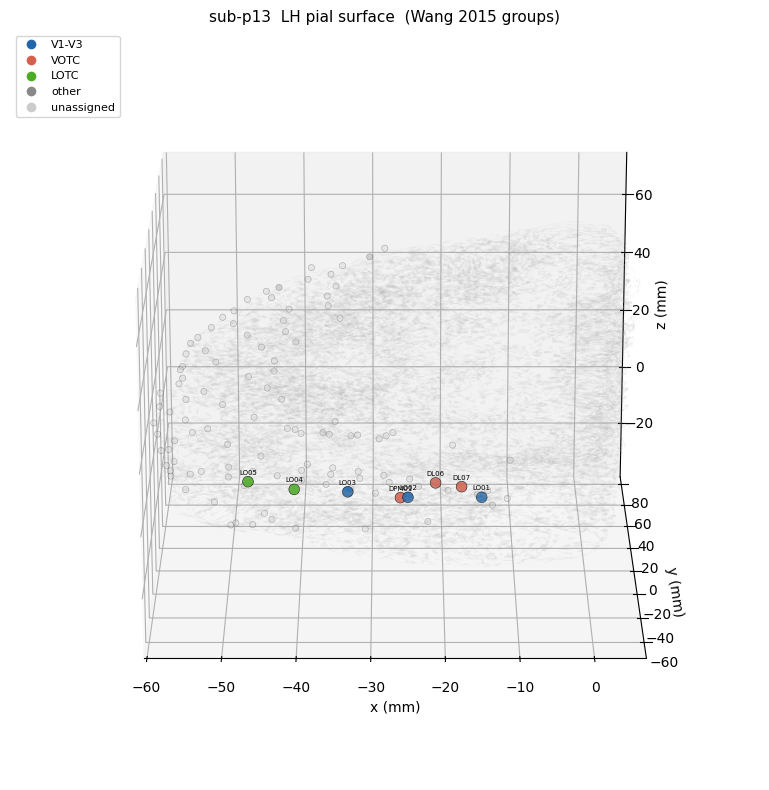

Saved: /Users/winstonluk/Documents/NEURON/FinalProject/results/milestone_01_pial_p13.png


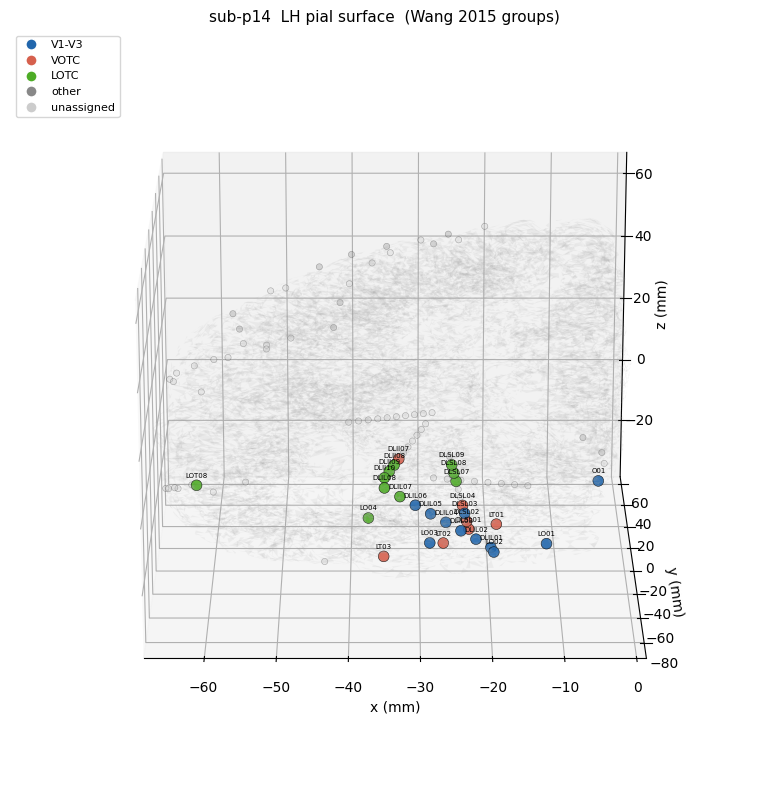

Saved: /Users/winstonluk/Documents/NEURON/FinalProject/results/milestone_01_pial_p14.png


In [8]:
# Generate 3-D plots for primary cohort
for sub in PRIMARY_SUBS:
    atlas = load_atlas_for_subject(sub)
    out_path = os.path.join(RESULTS_DIR, f'milestone_01_pial_{sub}.png')
    plot_electrodes_on_pial(sub, atlas, atlas_df, out_path)

## 6. Flat electrode-position plot — all 6 subjects (2-D summary)

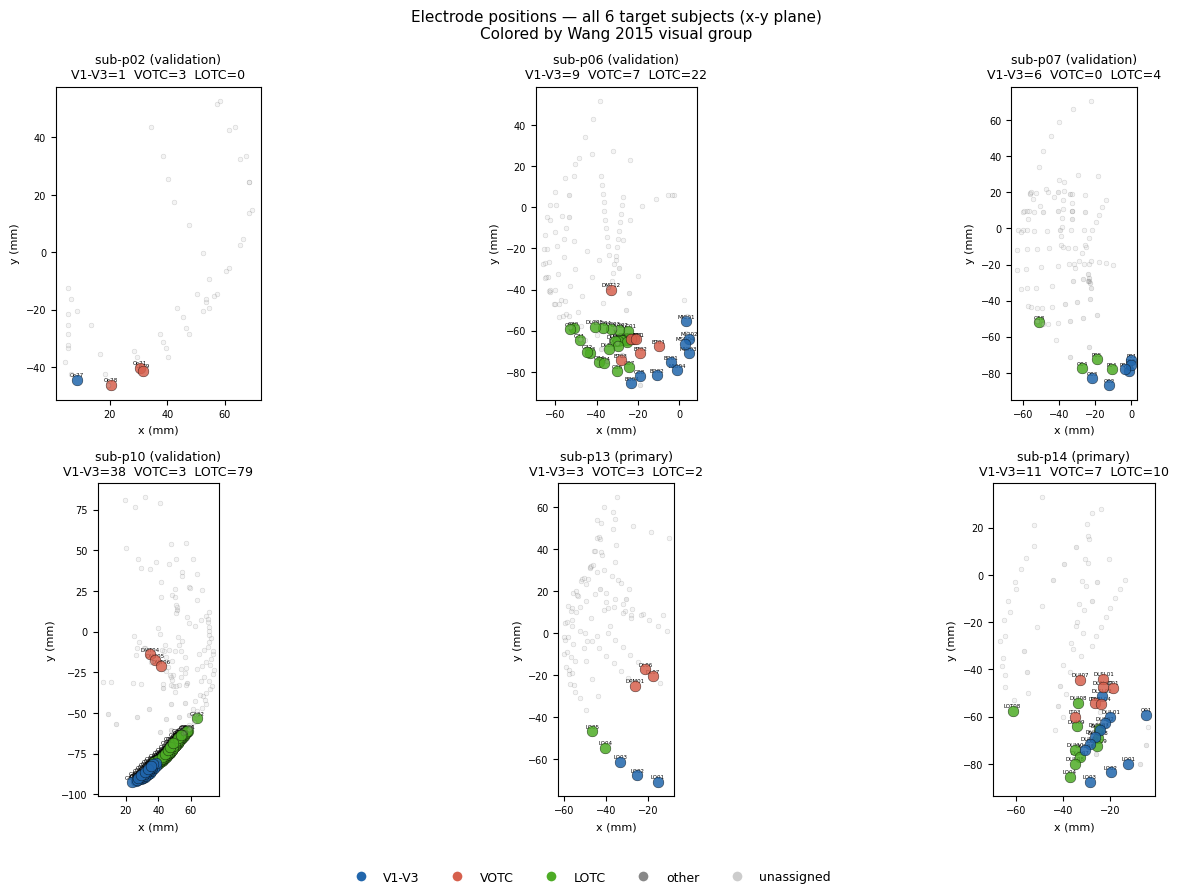

Saved: /Users/winstonluk/Documents/NEURON/FinalProject/results/milestone_01_electrodes_all_subjects.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, sub in zip(axes, TARGET_SUBS):
    df = atlas_df[atlas_df.subject == sub]
    role = 'primary' if sub in PRIMARY_SUBS else 'validation'

    for group, grp in df.groupby('visual_group'):
        c = GROUP_COLOR.get(group, '#999')
        s = 60 if group in ('V1-V3','VOTC','LOTC') else 12
        a = 0.85 if group in ('V1-V3','VOTC','LOTC') else 0.2
        ax.scatter(grp.x, grp.y, c=c, s=s, alpha=a,
                   label=group, edgecolors='k', linewidths=0.3, zorder=5)

    # Label visual electrodes
    for _, row in df[df.visual_group.isin(['V1-V3','VOTC','LOTC'])].iterrows():
        ax.text(row.x, row.y + 1, row.electrode, fontsize=4, ha='center', va='bottom')

    counts = df.visual_group.value_counts()
    title = (f'sub-{sub} ({role})\n'
             f'V1-V3={counts.get("V1-V3",0)}  '
             f'VOTC={counts.get("VOTC",0)}  '
             f'LOTC={counts.get("LOTC",0)}')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x (mm)', fontsize=8)
    ax.set_ylabel('y (mm)', fontsize=8)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)

# Shared legend
handles = [plt.Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=GROUP_COLOR[g], markersize=8, label=g)
           for g in ['V1-V3','VOTC','LOTC','other','unassigned']]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=9, frameon=False)
fig.suptitle('Electrode positions — all 6 target subjects (x-y plane)\nColored by Wang 2015 visual group',
             fontsize=11)
plt.tight_layout(rect=[0, 0.05, 1, 1])

out_all = os.path.join(RESULTS_DIR, 'milestone_01_electrodes_all_subjects.png')
plt.savefig(out_all, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_all}')

## 7. Wang probability heatmap — visual electrodes only

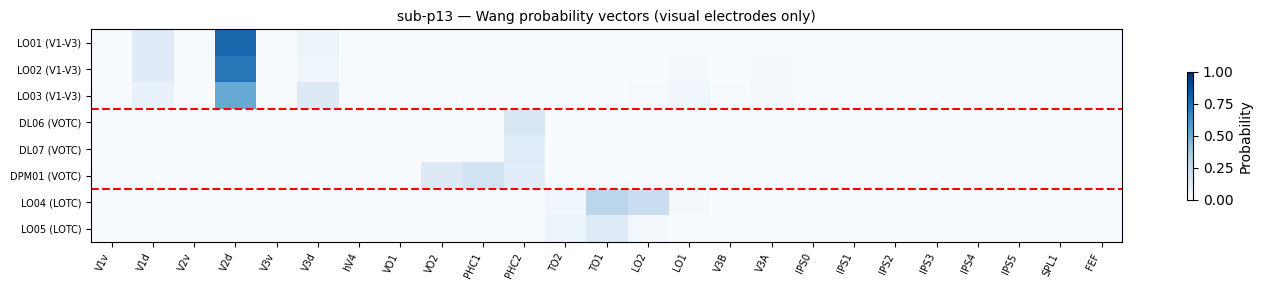

Saved: /Users/winstonluk/Documents/NEURON/FinalProject/results/milestone_01_wang_probs_p13.png


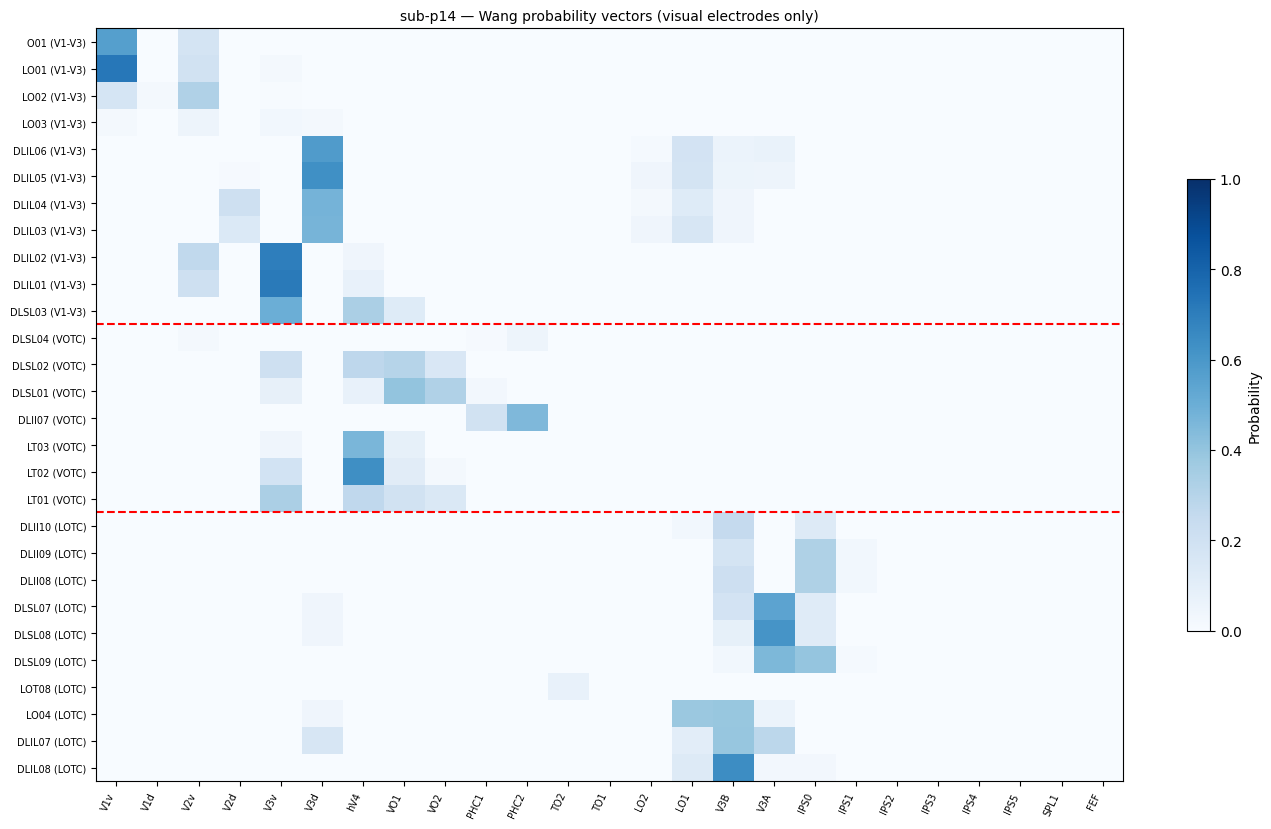

Saved: /Users/winstonluk/Documents/NEURON/FinalProject/results/milestone_01_wang_probs_p14.png


In [10]:
# Show full probability vectors for the visual electrodes in the primary cohort
# This is the data that downstream bootstrap grouping will operate on

for sub in PRIMARY_SUBS:
    vis = atlas_df[
        (atlas_df.subject == sub) &
        (atlas_df.visual_group.isin(['V1-V3', 'VOTC', 'LOTC']))
    ].copy().reset_index(drop=True)

    # Build probability matrix
    prob_mat = np.zeros((len(vis), len(WANG_AREAS)))
    for i, row in vis.iterrows():
        probs = json.loads(row.wang_probs)
        for j, area in enumerate(WANG_AREAS):
            prob_mat[i, j] = probs.get(area, 0.0)

    # Sort rows by visual_group then electrode name
    sort_key = {'V1-V3': 0, 'VOTC': 1, 'LOTC': 2}
    vis['_sort'] = vis.visual_group.map(sort_key)
    order = vis.sort_values('_sort').index
    prob_mat = prob_mat[order]
    row_labels = [f"{vis.loc[i,'electrode']} ({vis.loc[i,'visual_group']})"
                  for i in order]

    fig, ax = plt.subplots(figsize=(14, max(3, 0.3 * len(vis))))
    im = ax.imshow(prob_mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(WANG_AREAS)))
    ax.set_xticklabels(WANG_AREAS, rotation=65, ha='right', fontsize=7)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(row_labels, fontsize=7)
    ax.set_title(f'sub-{sub} — Wang probability vectors (visual electrodes only)', fontsize=10)
    plt.colorbar(im, ax=ax, label='Probability', shrink=0.6)

    # Dividers between groups
    grp_counts = vis.loc[order].visual_group.value_counts()
    cum = 0
    for g in ['V1-V3', 'VOTC']:
        cum += vis.loc[order].visual_group.eq(g).sum()
        ax.axhline(cum - 0.5, color='red', lw=1.5, linestyle='--')

    plt.tight_layout()
    out_hm = os.path.join(RESULTS_DIR, f'milestone_01_wang_probs_{sub}.png')
    plt.savefig(out_hm, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_hm}')

## 8. Final summary and exit criterion check

In [11]:
print('=' * 65)
print('MILESTONE 1 SUMMARY')
print('=' * 65)
print()

for sub in TARGET_SUBS:
    df = atlas_df[atlas_df.subject == sub]
    counts = df.visual_group.value_counts()
    max_dist = df.nearest_dist_mm.max()
    role = 'primary' if sub in PRIMARY_SUBS else 'validation'
    print(f'  sub-{sub} ({role}): total={len(df)}  '
          f'V1-V3={counts.get("V1-V3",0)}  '
          f'VOTC={counts.get("VOTC",0)}  '
          f'LOTC={counts.get("LOTC",0)}  '
          f'other={counts.get("other",0)}  '
          f'unassigned={counts.get("unassigned",0)}  '
          f'(max dist {max_dist:.1f} mm)')

print()
print('Published reference (Brands 2024 Table 3, primary cohort):')
print('  p13: 3 V1-V3 electrodes')
print('  p14: ~14 V1-V3, ~8 VOTC, ~9 LOTC  (pre-reliability-filter estimate)')
print()
print('Note: all Brands/Groen published counts include reliability filtering')
print('(split-half R² > 0.22) not applied here. Filtering is implemented in M3.')
print()

# Check p13 V1-V3 count
p13_v1v3 = int((atlas_df[(atlas_df.subject=='p13')].visual_group == 'V1-V3').sum())
p14_v1v3 = int((atlas_df[(atlas_df.subject=='p14')].visual_group == 'V1-V3').sum())
print(f'Exit criterion: p13 V1-V3 count = {p13_v1v3} (published: 3) -> '
      f'{"PASS" if abs(p13_v1v3 - 3) <= 1 else "CHECK"}')
print(f'Exit criterion: p14 V1-V3 count = {p14_v1v3} (published ~14) -> '
      f'{"PASS" if abs(p14_v1v3 - 14) <= 2 else "CHECK"}')
print()
print('Outputs written to results/:')
for f in sorted(os.listdir(RESULTS_DIR)):
    if 'milestone_01' in f:
        fp = os.path.join(RESULTS_DIR, f)
        print(f'  {f}  ({os.path.getsize(fp)/1e3:.0f} KB)')

MILESTONE 1 SUMMARY

  sub-p02 (validation): total=56  V1-V3=1  VOTC=3  LOTC=0  other=0  unassigned=52  (max dist 21.8 mm)
  sub-p06 (validation): total=142  V1-V3=9  VOTC=7  LOTC=22  other=10  unassigned=94  (max dist 8.1 mm)
  sub-p07 (validation): total=122  V1-V3=6  VOTC=0  LOTC=4  other=24  unassigned=88  (max dist 6.3 mm)
  sub-p10 (validation): total=252  V1-V3=38  VOTC=3  LOTC=79  other=17  unassigned=115  (max dist 6.2 mm)
  sub-p13 (primary): total=116  V1-V3=3  VOTC=3  LOTC=2  other=2  unassigned=106  (max dist 5.8 mm)
  sub-p14 (primary): total=94  V1-V3=11  VOTC=7  LOTC=10  other=12  unassigned=54  (max dist 10.9 mm)

Published reference (Brands 2024 Table 3, primary cohort):
  p13: 3 V1-V3 electrodes
  p14: ~14 V1-V3, ~8 VOTC, ~9 LOTC  (pre-reliability-filter estimate)

Note: all Brands/Groen published counts include reliability filtering
(split-half R² > 0.22) not applied here. Filtering is implemented in M3.

Exit criterion: p13 V1-V3 count = 3 (published: 3) -> PASS
Ex